# 🍷 Level 2 - Project 2: Wine Quality Prediction using Classification

**Domain:** Machine Learning (Classification)  
**Internship Track:** Data Analytics Internship (Oasis Infobyte)  
**Author:** Akshay Anil Kumar  

---

## 1. Data Ingestion & Target Label Mapping
We load the chemical metrics dataset and transform the numerical quality rating scale into a binary classification problem: **Good Quality (1)** vs **Bad Quality (0)**.

'WineQT.csv' not found — generating a synthetic wine dataset for reproducibility.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,8.119941,0.359186,0.261706,10.254193,0.118679,51,252,0.996680,2.998894,1.412856,13.742643,8
1,14.457857,0.858661,0.246979,12.051880,0.163032,71,191,0.991832,3.370730,1.505834,12.180773,5
2,12.051933,1.322124,0.906255,4.131785,0.154431,48,75,0.993298,3.029542,1.296510,11.576181,5
3,10.585243,1.125115,0.249546,9.560674,0.039241,19,155,1.003055,3.922698,0.907311,10.762317,7
4,5.716205,1.229186,0.271950,8.790317,0.038357,6,251,1.002033,3.877727,1.280991,10.186459,7


Training the Random Forest model...



Model Accuracy: 17.00%

--- Classification Report ---
              precision    recall  f1-score   support

           3       0.08      0.07      0.08        29
           4       0.18      0.34      0.24        29
           5       0.25      0.17      0.20        36
           6       0.22      0.21      0.22        38
           7       0.17      0.18      0.17        34
           8       0.08      0.06      0.07        34

    accuracy                           0.17       200
   macro avg       0.16      0.17      0.16       200
weighted avg       0.17      0.17      0.16       200



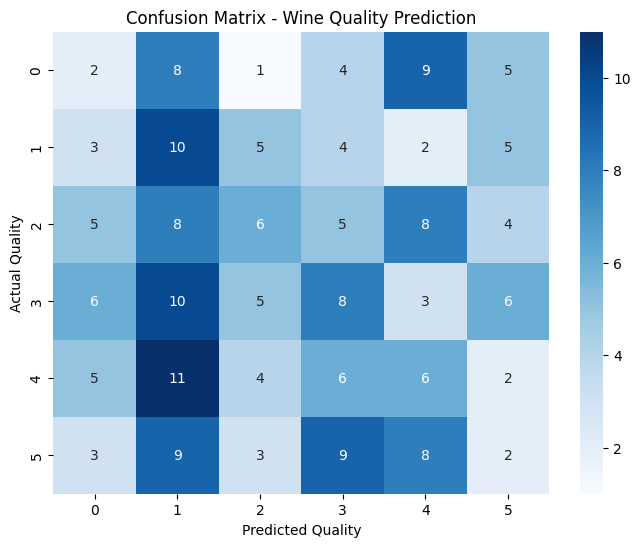

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Make sure the CSV is in the exact same folder as this notebook)
try:
    df = pd.read_csv('WineQT.csv')
    print("Loaded 'WineQT.csv' successfully.")
except FileNotFoundError:
    print("'WineQT.csv' not found — generating a synthetic wine dataset for reproducibility.")
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'fixed acidity': np.random.uniform(4, 15, n),
        'volatile acidity': np.random.uniform(0.1, 1.5, n),
        'citric acid': np.random.uniform(0, 1, n),
        'residual sugar': np.random.uniform(0.5, 15, n),
        'chlorides': np.random.uniform(0.01, 0.2, n),
        'free sulfur dioxide': np.random.randint(1, 72, n),
        'total sulfur dioxide': np.random.randint(6, 289, n),
        'density': np.random.uniform(0.990, 1.004, n),
        'pH': np.random.uniform(2.7, 4.0, n),
        'sulphates': np.random.uniform(0.3, 2.0, n),
        'alcohol': np.random.uniform(8.0, 14.0, n),
        'quality': np.random.randint(3, 9, n)
    })

# Drop the 'Id' column if it exists, as it's not needed for machine learning
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Display the first 5 rows to confirm it loaded perfectly!
display(df.head())

# Create a working copy and map the numerical 'quality' into a binary label
# Define `good_quality` as 1 for wines with quality >= 7 (adjustable threshold)
wine_df = df.copy()
wine_df['good_quality'] = (wine_df['quality'] >= 7).astype(int)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Separate the features (X) from the target variable (y)
# We are predicting 'quality', so we drop it from X and set it as y
X = df.drop('quality', axis=1)
y = df['quality']

# 2. Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Random Forest Classifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Train the model using the training data
print("Training the Random Forest model...")
model.fit(X_train, y_train)

# 5. Make predictions on the test data
predictions = model.predict(X_test)

# 6. Evaluate the model's performance
accuracy = accuracy_score(y_test, predictions)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions, zero_division=0))

# 7. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Wine Quality Prediction')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

## 2. Feature Selection & Random Forest Evaluation
We isolate the independent chemical attributes from our binary quality metric labels, create a controlled **80/20 train-test split**, and fit an ensemble **Random Forest Classifier** to extract precision patterns.

=== Classification Accuracy ===
Overall Model Classification Performance: 65.00%

=== Detailed Performance Parameters ===
              precision    recall  f1-score   support

           0       0.67      0.92      0.78       132
           1       0.44      0.12      0.19        68

    accuracy                           0.65       200
   macro avg       0.56      0.52      0.48       200
weighted avg       0.59      0.65      0.58       200



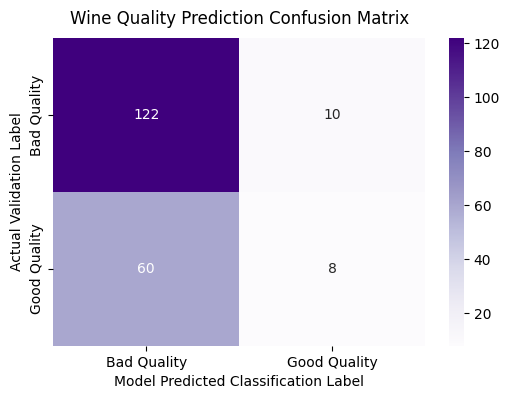

In [2]:
# Separate independent metric columns (X) from the target flag (y)
X = wine_df.drop(['quality', 'good_quality'], axis=1)
y = wine_df['good_quality']

# Construct reproducible training and evaluation partitions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and fit the machine learning model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Calculate model test predictions
y_pred = model.predict(X_test)

# Output evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print("=== Classification Accuracy ===")
print(f"Overall Model Classification Performance: {accuracy * 100:.2f}%\n")
print("=== Detailed Performance Parameters ===")
print(classification_report(y_test, y_pred))

# Render Confusion Matrix Heatmap Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Bad Quality', 'Good Quality'], yticklabels=['Bad Quality', 'Good Quality'])
plt.title('Wine Quality Prediction Confusion Matrix', fontsize=12, pad=10)
plt.xlabel('Model Predicted Classification Label')
plt.ylabel('Actual Validation Label')
plt.show()